In [1]:
import pandas as pd

### Load single-cell data

In [2]:
%%time
df = pd.read_pickle('/Users/dayn/data/macrohet_mac/verified_df.pkl')


CPU times: user 680 ms, sys: 360 ms, total: 1.04 s
Wall time: 1.19 s


In [4]:
df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
0,0.0,0.0,85.30408,914.186190,980.270593,0.0,0.0,1.0,716.326599,843.3125,...,NaN,0.0,0.0,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,0,7.0
1,0.5,NaN,85.30408,NaN,980.270593,NaN,0.0,1.0,716.326599,843.3125,...,NaN,0.0,0.5,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,1,7.0
2,1.0,NaN,85.30408,NaN,980.270593,NaN,0.0,1.0,716.326599,843.3125,...,NaN,0.0,1.0,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,2,7.0
3,1.5,NaN,85.30408,NaN,980.270593,NaN,0.0,1.0,716.326599,843.3125,...,NaN,0.0,1.5,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,3,7.0
4,2.0,NaN,85.30408,NaN,980.270593,NaN,0.0,1.0,716.326599,843.3125,...,NaN,0.0,2.0,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,4,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2007856,59.5,0.0,NaN,261.387613,NaN,False,0.0,0.0,1034.000000,1161.0000,...,NaN,0.0,58.5,0.0,None,None,None,-1.02,119,NaN
2007857,60.0,0.0,NaN,275.109568,NaN,False,0.0,0.0,972.000000,1147.0000,...,NaN,0.0,59.0,0.0,None,None,None,-1.02,120,NaN
2007858,60.5,0.0,NaN,404.484815,NaN,False,0.0,0.0,948.000000,1159.0000,...,NaN,0.0,59.5,0.0,None,None,None,-1.02,121,NaN
2007859,61.0,0.0,NaN,297.055758,NaN,NaN,0.0,0.0,874.000000,1163.0000,...,NaN,0.0,NaN,NaN,None,None,None,-1.02,122,NaN


/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_15050/44110149.py:98: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_15050/44110149.py:98: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_15050/44110149.py:98: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_15050/44110149.py:98: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_15050/44110149.py:98: Fut

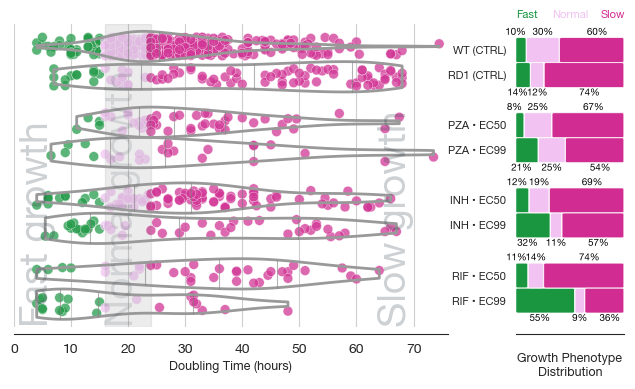

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

# --- Global Style & Font Settings ---
warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")
sns.set_style("white")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica Neue']
plt.rcParams['pdf.fonttype'] = 42 

# --- Contextual Definitions ---
growth_colors = {
    "Fast": '#1a9641',   # Deep Green
    "Normal": '#F1C2F2', # Light Pink/Purple
    "Slow": '#D02C91'    # Deep Magenta
}
growth_order = ["Fast", "Normal", "Slow"]

# Dimensions (200mm x 60mm)
width_mm = 200 
height_mm = 100
width_in = width_mm / 25.4
height_in = height_mm / 25.4

# --- Data Cleaning & Preparation ---
subset_df = df[df['mtb_origin'] == 'Growth'].copy()

# Normalize columns
for c in ["Compound", "Strain"]:
    if c in subset_df: 
        subset_df[c] = subset_df[c].astype(str)

# Initial clean of concentrations
subset_df["Concentration"] = subset_df.get("Concentration", "EC0").fillna("EC0").astype(str)
subset_df.loc[subset_df["Compound"] == "CTRL", "Concentration"] = "EC0"

# Flatten Doubling Times
subset_df = subset_df.explode("Doubling Times", ignore_index=True)
subset_df["Doubling Times"] = pd.to_numeric(subset_df["Doubling Times"], errors="coerce")
subset_df = subset_df.dropna(subset= ["Doubling Times"])
subset_df = subset_df[(subset_df["Doubling Times"] > 0) & (~np.isinf(subset_df["Doubling Times"]))]

# Deduplicate
keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in subset_df.columns]
subset_df = subset_df.drop_duplicates(subset=keys).copy()

# Re-Calculate Mask
mask_ctrl = subset_df["Compound"] == "CTRL"

# Binning
bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
subset_df["Growth Category"] = pd.cut(subset_df["Doubling Times"], bins=bins, labels=labels, right=False)

rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
subset_df["Strain_norm"] = np.where(subset_df["Strain"].isin(rd1_aliases), "RD1", "WT")

subset_df["Mtb Strain or Drug Compound"] = np.where(mask_ctrl, "CTRL", subset_df["Compound"])
subset_df["CTRL Type"] = np.where(mask_ctrl, subset_df["Strain_norm"], pd.NA)
subset_df["Display Compound"] = np.where(mask_ctrl, subset_df["Strain_norm"] + " (CTRL)", subset_df["Compound"])

# --- Configuration ---
strain_order = ["CTRL", "PZA", "INH", "RIF"]
# Order for the Right Panel (Bar Chart)
right_row_order = ["WT (CTRL)", "RD1 (CTRL)", "PZA", "INH", "RIF"]
conc_order = ["EC50", "EC0", "EC99"]

# --- Helper Function for Plotting (Updated Style) ---
def plot_overlay(ax, data, hue_col, hue_order):
    if data.empty: return

    # Stripplots FIRST (zorder 1) - Colored by Growth Category
    present_hues = [h for h in hue_order if h in data[hue_col].unique()]
    
    for cat in growth_order:
        cat_df = data[data["Growth Category"] == cat]
        if cat_df.empty: continue
        # Map specific growth color to the hue
        palette_map = {lvl: growth_colors[cat] for lvl in present_hues}
        
        sns.stripplot(
            data=cat_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue=hue_col, order=strain_order, hue_order=hue_order,
            dodge=True, palette=palette_map,
            jitter=0.25, size=7, linewidth=0.3, # Scaled down size
            edgecolor='white', alpha=0.75, ax=ax, zorder=1, legend=False
        )

    # Violins SECOND (zorder 2) - Transparent with quartiles
    white_palette = {h: "white" for h in hue_order}
    sns.violinplot(
        data=data, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue=hue_col, order=strain_order, hue_order=hue_order,
        dodge=True, inner="quartile", cut=0, scale='width',
        linewidth=2, linecolor='gray', palette=white_palette,
        saturation=1, ax=ax, zorder=2, legend=False
    )
    
    # Style Quartiles
    # Since we are calling this function multiple times on the same ax, 
    # we target only the lines just created is tricky. 
    # Easier to style ALL lines at the end or apply broadly.
    

# --- Figure Layout ---
fig = plt.figure(figsize=(width_in, height_in), constrained_layout=True)
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.25)
ax = plt.subplot(gs[0])
ax_bar = plt.subplot(gs[1])

# 1. Left Panel: Control Strips
ctrl_df_plot = subset_df[subset_df["Compound"] == "CTRL"]
if not ctrl_df_plot.empty:
    plot_overlay(ax, ctrl_df_plot, "CTRL Type", list(ctrl_df_plot["CTRL Type"].dropna().unique()))

# 2. Left Panel: Drug Strips
drug_df_plot = subset_df[subset_df["Compound"] != "CTRL"]
for compound in ["PZA", "INH", "RIF"]:
    sub = drug_df_plot[drug_df_plot["Mtb Strain or Drug Compound"] == compound]
    if not sub.empty:
        present_concs = [c for c in conc_order if c in sub["Concentration"].unique()]
        plot_overlay(ax, sub, "Concentration", present_concs)

# Global Line Styling (Apply to all violins created)
for line in ax.lines:
    line.set_linestyle('-')
    line.set_linewidth(0.8)
    line.set_color('gray')
    line.set_alpha(0.6)

for poly in ax.collections:
    if "PolyCollection" in str(type(poly)):
        poly.set_facecolor('none')

# Background Bands
xmax = subset_df["Doubling Times"].max() if not subset_df["Doubling Times"].isna().all() else 75
bands = [("Fast", bins[0], bins[1], 0.05), 
         ("Normal", bins[1], bins[2], 0.15), 
         ("Slow", bins[2], xmax+3, 0.05)]

for txt, b0, b1, alpha in bands:
    color = 'gray' if txt=='Normal' else 'white'        
    ax.axvspan(b0, b1, alpha=alpha, color=color)

# Rotated Annotations
ymax = len(strain_order) - 0.65
labels_info = [("Fast growth", 1, "left", 0.25), 
               ("Normal growth", 16, "left", 0.15), 
               ("Slow growth", 70, "right", 0.25)]

for txt, xpos, align, alpha in labels_info:
    ax.text(xpos, 0, txt, fontsize=28, color='#36454F', 
            alpha=alpha, ha=align, va='bottom', rotation=90,
            transform=ax.get_xaxis_transform()) # Stick to bottom

ax.set_xlabel("Doubling Time (hours)", fontsize=9, family='Helvetica Neue')
ax.set_ylabel("")
ax.set_yticks([]) # Hide Y ticks as legends or text labels might be better, or keep as is.
# Re-adding Y labels manually if needed, or relying on the legend/structure. 
# The original code removed yticks, so we keep that.

ax.xaxis.grid(True)
sns.despine(offset=5, left=True, ax=ax)

# --- Right Panel: Stacked Bars ---
g = (subset_df.groupby(["Display Compound", "Concentration", "Growth Category"], observed=True)
        .size().unstack("Growth Category", fill_value=0))

valid_rows = [(comp, conc) for comp in right_row_order for conc in conc_order 
              if (comp, conc) in g.index and g.loc[(comp, conc)].sum() > 0]

if valid_rows:
    g = g.loc[pd.MultiIndex.from_tuples(valid_rows, names=["Display Compound", "Concentration"])]
    props = g.div(g.sum(axis=1), axis=0).fillna(0.0)

    y_pos = []
    last_group = None 
    current_y = 0
    group_gap = 0.5
    bar_height = 0.5 # Matches previous plot style
    
    for comp, conc in props.index:
        current_group = "CTRL_GROUP" if "(CTRL)" in comp else comp
        if last_group is not None:
            if current_group == last_group:
                current_y += bar_height
            else:
                current_y += (bar_height + group_gap)
        y_pos.append(current_y)
        last_group = current_group
        
    y_pos = np.array(y_pos)
    lefts = np.zeros(len(props))
    
    for gr in growth_order:
        if gr not in props.columns: continue
        vals = props[gr].values
        bars = ax_bar.barh(y_pos, vals, left=lefts, height=bar_height, 
                           label=gr, color=growth_colors[gr], edgecolor="none")
        
        # Rounded Edges
        for idx, bar in enumerate(bars):
            width = bar.get_width()
            if width <= 0: continue
            fancy_box = mpatches.FancyBboxPatch(
                (bar.get_x(), bar.get_y()), width, bar.get_height(),
                boxstyle="round,pad=-0.005,rounding_size=0.04",
                facecolor=bar.get_facecolor(), edgecolor="white", linewidth=0.5, mutation_scale=0.5
            )
            ax_bar.add_patch(fancy_box)
            bar.set_visible(False)

        # Percentage Labels
        shift_amount = 0.35
        for i, (bar, v) in enumerate(zip(bars, vals)):
            if v > 0.05: 
                # Start with standard center
                x_center = bar.get_x() + bar.get_width() / 2
                
                # --- NEW SHIFT LOGIC ---
                # Nudge Fast labels Left and Slow labels Right to separate them
                if gr == "Fast":
                    x_center -= 0.05  # Push Left
                elif gr == "Slow":
                    x_center += 0.05  # Push Right
                # -----------------------

                # Vertical Alternating Logic
                base_y = bar.get_y() + bar.get_height() / 2
                y_center = base_y - shift_amount - 0.005 if i % 2 == 0 else base_y + shift_amount + 0.005
                
                # Path Effects Text
                txt = ax_bar.text(x_center, y_center, f"{v*100:.0f}%", 
                            ha="center", va="center", fontsize=7, fontweight="bold",
                            color='black', family='Helvetica Neue')
                txt.set_path_effects([path_effects.withStroke(linewidth=1.5, foreground='white')])
                                      
        lefts += vals

    ax_bar.set(xlim=(0, 1), xticks=[], yticks=y_pos, ylabel="", xlabel="\nGrowth Phenotype\nDistribution")
    ax_bar.xaxis.get_label().set_fontsize(9)
    
    # Y Labels
    labels = [f"{c} • {conc}" if conc != 'EC0' else c for c, conc in props.index]
    ax_bar.set_yticklabels(labels)
    plt.setp(ax_bar.get_yticklabels(), fontweight='bold', fontsize=8, family='Helvetica Neue')
    ax_bar.invert_yaxis()
    sns.despine(offset=5, left=True, ax=ax_bar)

    # Fixed Headers
    fixed_x_positions = {"Fast": 0.1, "Normal": 0.5, "Slow": 0.9}
    for gr in growth_order:
        ax_bar.text(fixed_x_positions[gr], -0.6, gr, ha='center', va='bottom', 
                    fontsize=8, fontweight='bold', color=growth_colors[gr], family='Helvetica Neue')

else:
    ax_bar.axis("off")

ax.set_xlim(0, 76)


plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/final_final_final/f3.pdf',
            bbox_inches='tight', dpi=314)
plt.show()